Решить задачу классификации изображений с помощью многослойного персептрона:
1. Сравнить время обучения на CPU и GPU. 
1. Построить графики ошибки (loss) на train/test подвыборке.
2. Построить графики точности (accuracy) на train/test подвыборке.
3. Оценить качество обучения.
4. Происходит ли переобучение?
5. Происходит ли паралич сети?
6. Добавить early stopping.

In [23]:
import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [24]:
import torchvision.datasets
MNIST_train = torchvision.datasets.MNIST('./', download=False, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=False, train=False)

In [25]:
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

In [26]:
X_train.dtype, y_train.dtype

(torch.uint8, torch.int64)

In [27]:
X_train = X_train.float()
X_test = X_test.float()

In [29]:
X_train.shape, X_test.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [30]:
y_train.shape, y_test.shape

(torch.Size([60000]), torch.Size([10000]))

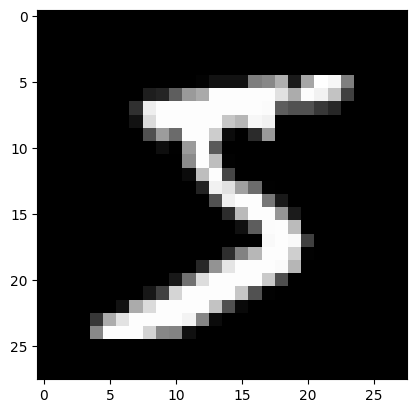

tensor(5)


In [31]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0, :, :], cmap="gray")
plt.show()
print(y_train[0])

Преобразование входных данных

In [33]:
X_train = X_train.reshape([-1, 28 * 28])
X_test = X_test.reshape([-1, 28 * 28])

In [ ]:
n_input = 28 * 28 # количество параметров (кол-во пикселей)
n_hidden_neurons = 128
n_output = 10 # количество классов (в задаче 10 классов)

class MNISTNet(torch.nn.Module):
    def __init__(self, n_hidden_neurons):
        super(MNISTNet, self).__init__()
        self.fc1 = torch.nn.Linear(n_input, n_hidden_neurons)
        self.ac1 = torch.nn.Sigmoid()
        self.fc2 = torch.nn.Linear(n_hidden_neurons, n_output) 
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.ac1(x)
        x = self.fc2(x)
        return x
    
mnist_net = MNISTNet(n_hidden_neurons)

In [41]:
torch.cuda.is_available()

False

In [43]:
# !nvidia-smi

In [44]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

mnist_net = mnist_net.to(device)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

list(mnist_net.parameters())

Using device: cpu


[Parameter containing:
 tensor([[-0.0003,  0.0192, -0.0294,  ...,  0.0219,  0.0037,  0.0021],
         [-0.0198, -0.0150, -0.0104,  ..., -0.0203, -0.0060, -0.0299],
         [-0.0201,  0.0149, -0.0333,  ..., -0.0203,  0.0012,  0.0080],
         ...,
         [ 0.0018, -0.0295,  0.0085,  ..., -0.0037,  0.0036,  0.0300],
         [-0.0233, -0.0220, -0.0064,  ...,  0.0115, -0.0324, -0.0158],
         [ 0.0309,  0.0066,  0.0125,  ...,  0.0286,  0.0350, -0.0105]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0321, -0.0053,  0.0045, -0.0211,  0.0224,  0.0130,  0.0158,  0.0272,
          0.0240, -0.0157, -0.0089,  0.0221,  0.0055,  0.0071, -0.0031, -0.0249,
         -0.0334, -0.0024, -0.0124,  0.0129, -0.0047, -0.0190, -0.0051,  0.0227,
          0.0324, -0.0356,  0.0029, -0.0081,  0.0255, -0.0104, -0.0205, -0.0056,
          0.0218, -0.0106,  0.0032,  0.0340, -0.0189, -0.0079, -0.0206, -0.0077,
         -0.0113,  0.0232,  0.0032, -0.0164, -0.0082,  0.0203, -0.0323, -0.0244

In [45]:
loss = torch.nn.CrossEntropyLoss() # классификация, поэтому Энтропия

optimizer = torch.optim.SGD(mnist_net.parameters(), lr=1.0e-3) # стохастический градиентный спуск lr - скорость обучения

# optimizer = torch.optim.Adam(mnist_net.parameters(), lr=1.0e-3)

In [47]:
import time

batch_size = 256 # размер батча исходя из задачи, датасета, размер памяти. Слишком большой батч - слишком большое обобшение. Слишком маленький батч - нестабильность обучения
n_epochs = 50
patience = 5

train_accuracy_history = []
train_loss_history = []
test_accuracy_history = []
test_loss_history = []

best_loss = None
epochs_no_improve = 0

start_time = time.time()

for epoch in range(n_epochs):
    order = np.random.permutation(len(X_train))
    
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad() # обнуляем градиенты
        
        batch_indexes = order[start_index:start_index+batch_size] # перемешиваем индексы - моделируем шафл на каждой итерации. Если не делать шафл, то сеть может подумать, что порядок элементов имеет значение
        
        X_batch = X_train[batch_indexes]
        y_batch = y_train[batch_indexes]
        
        preds = mnist_net.forward(X_batch) 
        
        loss_value = loss(preds, y_batch)
        loss_value.backward() # построение вычислительного графа и построение диференциированной сети от начала к концу. Посчитали все весы, градиенты и баесы
        
        optimizer.step() # обновляет веса

    # train metrics
    with torch.no_grad():
        train_preds = mnist_net(X_train)
        train_loss = loss(train_preds, y_train)
        train_accuracy = (train_preds.argmax(dim=1) == y_train).float().mean()

        train_loss_history.append(train_loss.item())
        train_accuracy_history.append(train_accuracy.item())

        # test metrics
        test_preds = mnist_net(X_test)
        test_loss = loss(test_preds, y_test)
        test_accuracy = (test_preds.argmax(dim=1) == y_test).float().mean()

        test_loss_history.append(test_loss.item())
        test_accuracy_history.append(test_accuracy.item())

    # early stopping по loss на test
    if best_loss is None or test_loss.item() < best_loss - 1e-4:
        best_loss = test_loss.item()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping на эпохе {epoch + 1}")
            break

    print(f"Epoch {epoch + 1}/{n_epochs} | train_acc={train_accuracy.item():.4f} | test_acc={test_accuracy.item():.4f}")

end_time = time.time()
print(f"Training time on {device}: {end_time - start_time:.2f} sec")

Epoch 1/50 | train_acc=0.9259 | test_acc=0.9198
Epoch 2/50 | train_acc=0.9266 | test_acc=0.9196
Epoch 3/50 | train_acc=0.9266 | test_acc=0.9196
Epoch 4/50 | train_acc=0.9275 | test_acc=0.9200
Epoch 5/50 | train_acc=0.9278 | test_acc=0.9203
Epoch 6/50 | train_acc=0.9283 | test_acc=0.9207
Epoch 7/50 | train_acc=0.9288 | test_acc=0.9211
Epoch 8/50 | train_acc=0.9295 | test_acc=0.9216
Epoch 9/50 | train_acc=0.9297 | test_acc=0.9216
Epoch 10/50 | train_acc=0.9301 | test_acc=0.9213
Epoch 11/50 | train_acc=0.9305 | test_acc=0.9216
Epoch 12/50 | train_acc=0.9310 | test_acc=0.9223
Epoch 13/50 | train_acc=0.9311 | test_acc=0.9220
Epoch 14/50 | train_acc=0.9315 | test_acc=0.9223
Epoch 15/50 | train_acc=0.9324 | test_acc=0.9222
Epoch 16/50 | train_acc=0.9324 | test_acc=0.9227
Epoch 17/50 | train_acc=0.9329 | test_acc=0.9231
Epoch 18/50 | train_acc=0.9331 | test_acc=0.9229
Epoch 19/50 | train_acc=0.9335 | test_acc=0.9224
Epoch 20/50 | train_acc=0.9337 | test_acc=0.9225
Epoch 21/50 | train_acc=0.934

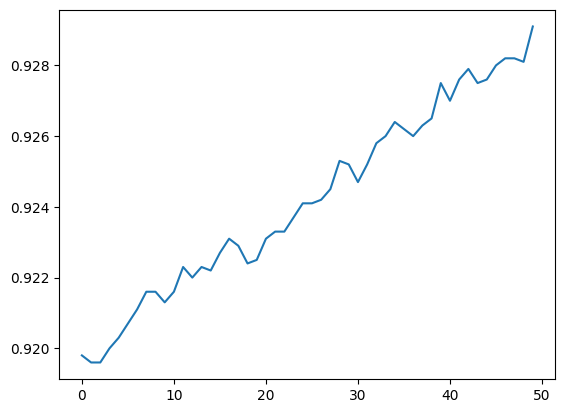

In [48]:
plt.plot(test_accuracy_history)
# plt.plot(train_accuracy_history)

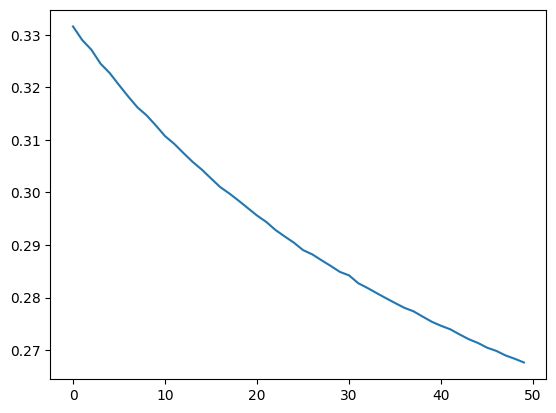

In [49]:
plt.plot(test_loss_history)
# plt.plot(train_loss_history)